# Welcome to torch!

## Import Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

## Defining Data

In [3]:
# Distance in miles
distances = torch.tensor([[1.0], [2.0], [3.0], [4.0]], dtype=torch.float32)
# Delivery times in minutes
times = torch.tensor([[6.96], [12.11], [16.77], [22.21]], dtype=torch.float32)

## Model Building

In [4]:
#define the model
model = nn.Sequential(nn.Linear(1, 1)) #take 1 input and produce 1 output

## Loss function and optimizer

In [5]:
# Define the loss function and optimizer
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

## Training

In [7]:
# Training loop
for epoch in range (500):
    #0. Reset the optimizer
    optimizer.zero_grad()
    #1. Make the predictions
    outputs = model(distances)
    #2. Calculate the loss
    loss = loss_function(outputs, times)
    #3. Calculate adjustments
    loss.backward()
    #4. Update the model
    optimizer.step()
    if (epoch + 1) % 50 == 0:
        print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')

Epoch: 50, Loss: 0.026917897164821625
Epoch: 100, Loss: 0.02652924321591854
Epoch: 150, Loss: 0.02624100260436535
Epoch: 200, Loss: 0.026027722284197807
Epoch: 250, Loss: 0.025869596749544144
Epoch: 300, Loss: 0.025752512738108635
Epoch: 350, Loss: 0.025665635243058205
Epoch: 400, Loss: 0.02560131624341011
Epoch: 450, Loss: 0.025553598999977112
Epoch: 500, Loss: 0.025518476963043213


## Inference

In [9]:
distance_to_predict = 7.0
with torch.no_grad():
    test_distance = torch.tensor([[distance_to_predict]], dtype=torch.float32)
    predicted_time = model(test_distance)
    print(f"predicted time for 25 miles: {predicted_time.item()} minutes")

predicted time for 25 miles: 37.23085403442383 minutes


In [10]:
# Access the first (and only) layer in the sequential model
layer = model[0]

# Get weights and bias
weights = layer.weight.data.numpy()
bias = layer.bias.data.numpy()

print(f"Weight: {weights}")
print(f"Bias: {bias}")

Weight: [[5.049339]]
Bias: [1.885483]


## test on new dataset

In [11]:
# Combined dataset: bikes for short distances, cars for longer ones
new_distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
new_times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

In [13]:
with torch.no_grad():
    new_predicted_time = model(new_distances)

In [16]:
# Calculate the new loss
new_loss = loss_function(new_predicted_time, new_times)
print(f"Loss on new, combined data: {new_loss.item():.2f}")

Loss on new, combined data: 175.39


/var/folders/m5/nm29s0jd4wsf1qb6g7qj151m0000gn/T/ipykernel_94352/3691610268.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  predicted_line = (new_distances * weights) + bias


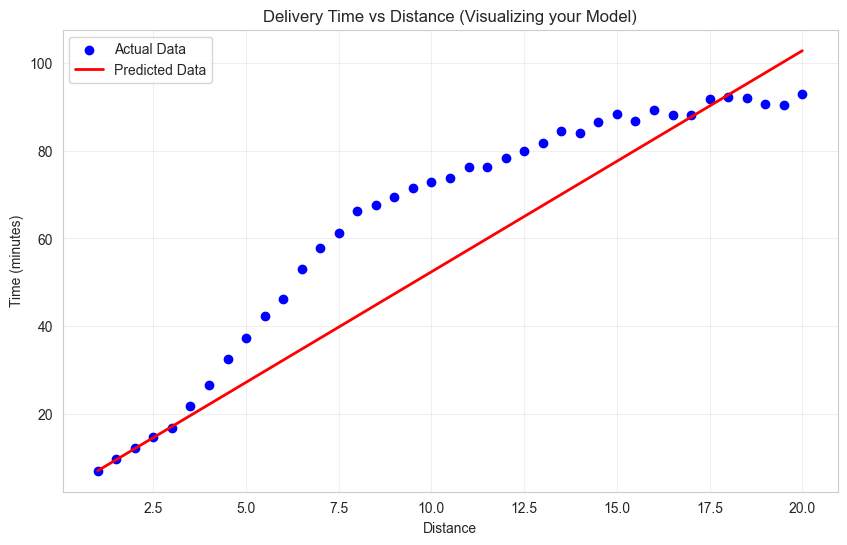

In [20]:
import matplotlib.pyplot as plt
predicted_line = (new_distances * weights) + bias
plt.figure(figsize=(10, 6))
plt.scatter(new_distances.numpy(), new_times.numpy(), color='blue', label='Actual Data')
plt.plot(new_distances.numpy(), predicted_line.numpy(), color='red', linewidth=2, label='Predicted Data')
plt.title('Delivery Time vs Distance (Visualizing your Model)')
plt.xlabel('Distance')
plt.ylabel('Time (minutes)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()